# Performance Test 

The test will plot the ROC of the algorithms. There are two modes: Full which test both non conjugate and conjugate SCD; limited which test only non conjugate SCD and with limited range.

The algorithm ability to detect cycle frequency under heavy noise will determine its performance. The cycle frequency tested are:

- Non Conjugate:
    - Rect BPSK: 0.4 Hz 
    - SRRC QPSK: 0.1 Hz 
    - GMSK: 0.1 Hz 

- Conjugate:
    - Rect BPSK: 0.5 Hz 
    - MSK: 0.25 Hz 
    - GMSK: 0.15 Hz 

The signal paramters are 0.1 Hz Symbol Rate, 0.05 Hz CFO, SRRC filter length of 21, SRRC beta of 0.1 and Bandwidth time product of 0.3 for GMSK.

Usage:

```
plot_roc_non_conjugate(func_lambda, Np=8, no_of_simulation=1000, threshold_resolution=10000, snr=[0], N=2**12, fam=False, L=2, name="roc", save=False)

plot_roc_conjugate(func_lambda, Np=8, no_of_simulation=1000, threshold_resolution=10000, snr=[0], N=2**12, fam=False, L=2, name="roc", save=False)
```

The higher the snr, the easier the test. Same for N (signal length).

In [1]:
import numpy as np
import scf_test.tests as test
from scf_test.algorithm import ssca, fam, fast_sc_wrapper, ssca_flattop, fam_flattop

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.733/3
-5dB SNR Score: 1.624/3
-10dB SNR Score: 1.520/3


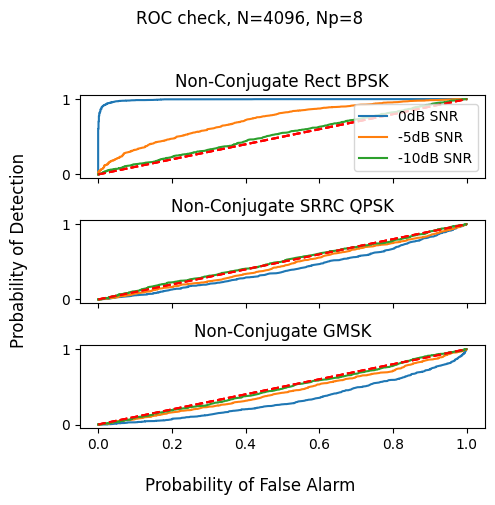

In [2]:
fam_nc_pd, fam_nc_pf, fam_nc_roc_auc, threshold_resolution = test.plot_roc_non_conjugate(fam, Np=8, L=2, fam=True, snr=[0, -5, -10], name="fam_roc") # fam=True for L paramter

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.877/3
-5dB SNR Score: 1.735/3
-10dB SNR Score: 1.528/3


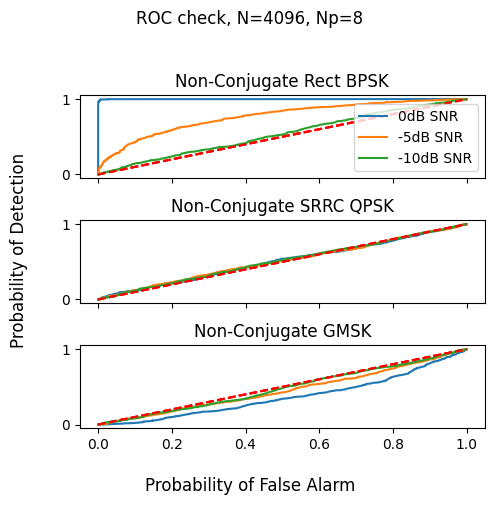

In [3]:
ssca_pd, ssca_pf, ssca_roc_auc, threshold_resolution = test.plot_roc_non_conjugate(ssca, Np=8, snr=[0, -5, -10], name="ssca_roc") 

For algorithm that only outputs non conjugate SCD and have limited cycle frequency range like FastSC, we have a modified version of the test for them.

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.948/3
-5dB SNR Score: 1.755/3
-10dB SNR Score: 1.520/3


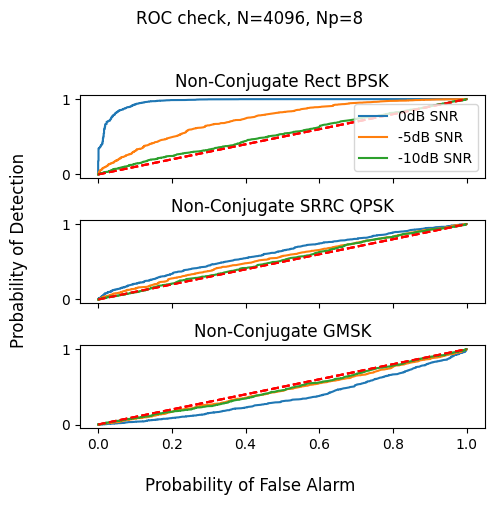

In [4]:
fastsc_pd_limited, fastsc_pf_limited, fastsc_roc_auc_limited, threshold_resolution = test.plot_roc_non_conjugate(fast_sc_wrapper, Np=8, snr=[0, -5, -10], name="fastsc_roc") 

You can try changing the parameters of the test like N, Np and SNR.

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
-10dB SNR Score: 2.594/3


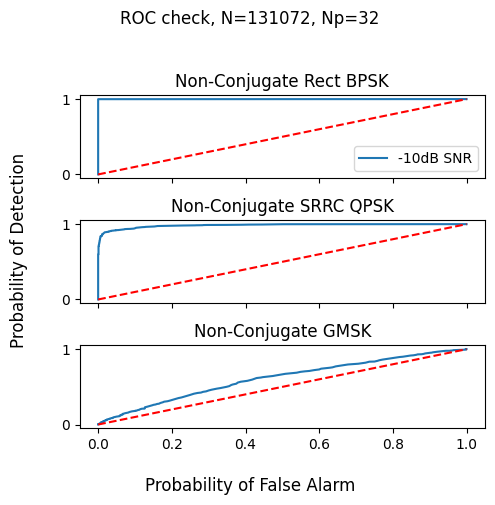

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
-10dB SNR Score: 2.472/3


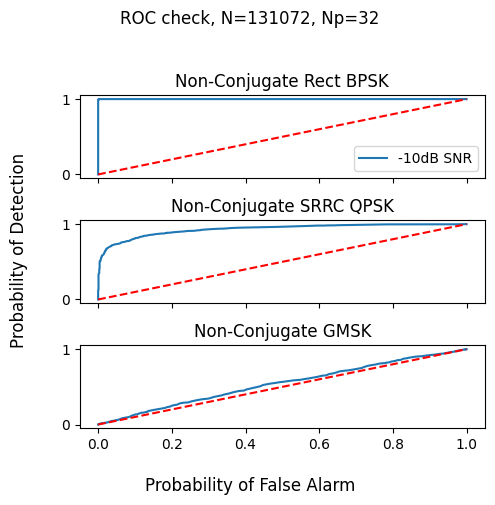

In [2]:
# Long signal length. The performance should improve here
fam_nc_pd, fam_nc_pf, fam_nc_roc_auc, threshold_resolution = test.plot_roc_non_conjugate(fam, Np=32, L=8, fam=True, snr=[-10], N=2**17, name="fam_roc") # fam=True for L parameter
ssca_pd, ssca_pf, ssca_roc_auc, threshold_resolution = test.plot_roc_non_conjugate(ssca, Np=32, snr=[-10], N=2**17, name="ssca_roc")
